## Análisis de datos II - Clase 2
---

### Detección de drift con Evidently AI
---

In [22]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from evidently import Report, Dataset, DataDefinition
from evidently.metrics import ValueDrift
from evidently.presets import DataDriftPreset
import webbrowser
import os

### Usamos el dataset de pingüinos pero vamos a simular drift

#### Supongamos que se trata de un problema de clasificación, y queremos predecir la especie del pingüino (target = species) a partir de los features que indican largo del pico, de las aletas, peso, sexo, isla en la que habitan, etc.

In [ ]:
df = sns.load_dataset("penguins").dropna()

# Armamos una muestra de referencia que simula ser los datos de entrenamiento (tomamos 50% de los datos)
reference = df.sample(frac=0.5, random_state=42)

# Al 50% restante los vamos a usar como datos "nuevos" (de producción)
# A estos datos les vamos a simular drift
actual_base = df.drop(reference.index)

print("Distribución de la target "species" en el dataset de referencia:")
print(reference["species"].value_counts(normalize=True))

print("\nDistribución en actual_base (ANTES de simular shift):")
print(actual_base["species"].value_counts(normalize=True))

Distribución en reference:
species
Adelie       0.451807
Gentoo       0.337349
Chinstrap    0.210843
Name: proportion, dtype: float64

Distribución en actual_base (ANTES de simular shift):
species
Adelie       0.425150
Gentoo       0.377246
Chinstrap    0.197605
Name: proportion, dtype: float64


---
#### 1. Covariate shift (Cambia la distribución de los datos de entrada)
---

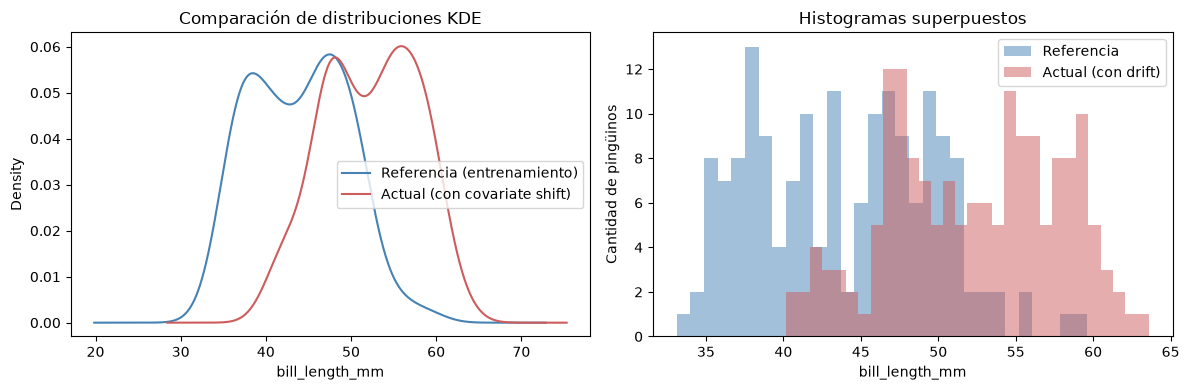

In [24]:
# Simulamos que en producción llegan datos de pingüinos con picos más largos

np.random.seed(1)
covariate_shift = actual_base.copy()

# Simulamos un drift en la variable "bill_length_mm" agregando ruido gaussiano
covariate_shift["bill_length_mm"] = covariate_shift["bill_length_mm"] + np.random.normal(8, 2, size=len(covariate_shift))

# Graficamos para verificar que generamos bien el covariate shift.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE
reference["bill_length_mm"].plot(kind="kde", label="Referencia (entrenamiento)", ax=axes[0], color="steelblue")
covariate_shift["bill_length_mm"].plot(kind="kde", label="Actual (con covariate shift)", ax=axes[0], color="indianred")
axes[0].set_title("Comparación de distribuciones KDE")
axes[0].set_xlabel("bill_length_mm")
axes[0].legend()

# Histogramas - Notar que usamos density = True que ajusta el área bajo la curva a 1, para poder comparar con la KDE
axes[1].hist(reference["bill_length_mm"], bins=30, alpha=0.5, label="Referencia", color="steelblue")
axes[1].hist(covariate_shift["bill_length_mm"], bins=30, alpha=0.5, label="Actual (con drift)", color="indianred")
axes[1].set_title("Histogramas superpuestos")
axes[1].set_ylabel("Cantidad de pingüinos")
axes[1].set_xlabel("bill_length_mm")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Ahora calculamos las métricas con Evidently

In [25]:
# Primero instancio los datasets en Evidently a partir del dataframe con covariate shift
ref_dataset = Dataset.from_pandas(reference, data_definition=DataDefinition())
covariate_dataset = Dataset.from_pandas(covariate_shift, data_definition=DataDefinition())

# Defino un reporte con las métodos que quiero
report_covariate = Report(metrics=[
    ValueDrift(column="bill_length_mm", method="ks"),
    ValueDrift(column="bill_length_mm", method="psi"),
    ValueDrift(column="bill_length_mm", method="kl_div"),
    ValueDrift(column="bill_length_mm", method="jensenshannon"),
])

# Corro el reporte con los datasets que instancié
resultado_covariate = report_covariate.run(covariate_dataset, ref_dataset)

for m in resultado_covariate.dict()["metrics"]:
    print(m["metric_name"], "->", round(m["value"], 4))

ValueDrift(column=bill_length_mm,method=ks,threshold=0.05) -> 0.0
ValueDrift(column=bill_length_mm,method=psi,threshold=0.1) -> 3.4777
ValueDrift(column=bill_length_mm,method=kl_div,threshold=0.1) -> 2.1805
ValueDrift(column=bill_length_mm,method=jensenshannon,threshold=0.1) -> 0.4857


---
#### 2. Label shift (Cambia la distribución de la target)
---

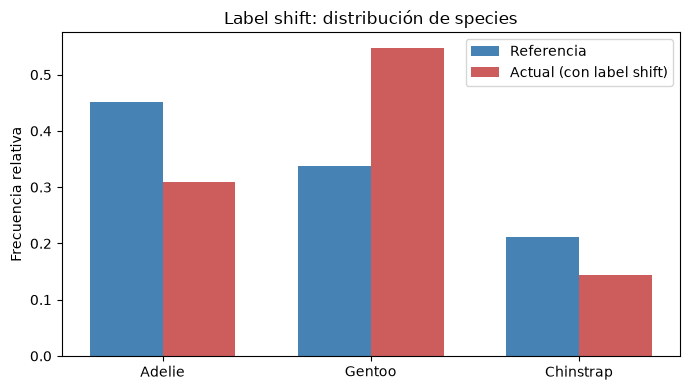

In [26]:

# Para simular un label shift, sobremuestreamos la especie Gentoo en el dataset "actual"
gentoo = actual_base[actual_base["species"] == "Gentoo"]
otros = actual_base[actual_base["species"] != "Gentoo"]
label_shift = pd.concat([otros, gentoo, gentoo])


# Visualizamos las distribuciones de la variable species

frecuencias_ref = reference["species"].value_counts(normalize=True)
frecuencias_actual = label_shift["species"].value_counts(normalize=True)

especies = frecuencias_ref.index  # mismo orden para ambas barras
x = np.arange(len(especies))
ancho = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - ancho/2, frecuencias_ref[especies], ancho, label="Referencia", color="steelblue")
ax.bar(x + ancho/2, frecuencias_actual[especies], ancho, label="Actual (con label shift)", color="indianred")

ax.set_xticks(x)
ax.set_xticklabels(especies)
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Label shift: distribución de species")
ax.legend()

plt.tight_layout()
plt.show()



In [27]:
# Defino el dataset de Evidently a partir del dataframe con label shift
label_shift_dataset = Dataset.from_pandas(label_shift, data_definition=DataDefinition())

# Defino el reporte
report_label = Report(metrics=[
    ValueDrift(column="species", method="psi"),
    ValueDrift(column="species", method="kl_div"),
    ValueDrift(column="species", method="jensenshannon"),
])
resultado_label = report_label.run(label_shift_dataset, ref_dataset)

for m in resultado_label.dict()["metrics"]:
    print(m["metric_name"], "->", round(m["value"], 4))

ValueDrift(column=species,method=psi,threshold=0.1) -> 0.1825
ValueDrift(column=species,method=kl_div,threshold=0.1) -> 0.0897
ValueDrift(column=species,method=jensenshannon,threshold=0.1) -> 0.1504


---
#### 3. Concept Drift (Cambia la relación entre features y target)
---

In [28]:
# Invertimos la relación entre bill_length_mm y species
concept_drift = actual_base.copy()
concept_drift.loc[concept_drift["bill_length_mm"] > concept_drift["bill_length_mm"].median(), "species"] = "Adelie"

# Defino el dataset de Evidently
concept_dataset = Dataset.from_pandas(concept_drift, data_definition=DataDefinition())

# Reporte
report_concept = Report(metrics=[
    ValueDrift(column="bill_length_mm", method="ks"),
    ValueDrift(column="bill_length_mm", method="psi"),
    ValueDrift(column="bill_length_mm", method="kl_div"),
    ValueDrift(column="bill_length_mm", method="jensenshannon"),
])

# Ejecutamos
resultado_concept = report_concept.run(concept_dataset, ref_dataset)


for m in resultado_concept.dict()["metrics"]:
    print(m["metric_name"], "->", round(m["value"], 4))


ValueDrift(column=bill_length_mm,method=ks,threshold=0.05) -> 0.5418
ValueDrift(column=bill_length_mm,method=psi,threshold=0.1) -> 0.1233
ValueDrift(column=bill_length_mm,method=kl_div,threshold=0.1) -> 0.0792
ValueDrift(column=bill_length_mm,method=jensenshannon,threshold=0.1) -> 0.1113


#### ¿Y si en vez de mirar uno por uno los features con drift, analizamos todos juntos?

In [29]:
# Armamos un dataset con los 3 tipos de drift que simulamos
actual_consolidado = actual_base.copy()

# Covariate shift en bill_length_mm
np.random.seed(1)
actual_consolidado["bill_length_mm"] = actual_consolidado["bill_length_mm"] + np.random.normal(8, 2, size=len(actual_consolidado))

# Label shift en species (sobremuestreamos Gentoo)
gentoo_idx = actual_consolidado[actual_consolidado["species"] == "Gentoo"].index
filas_extra = actual_consolidado.loc[gentoo_idx]
actual_consolidado = pd.concat([actual_consolidado, filas_extra])

# Concept drift: invertimos la relación bill_length_mm -> species
actual_consolidado.loc[actual_consolidado["bill_length_mm"] > actual_consolidado["bill_length_mm"].median(), "species"] = "Adelie"

consolidado_drift = Dataset.from_pandas(actual_consolidado, data_definition=DataDefinition())

In [30]:
# Armamos otro tipo de reporte, un DataDriftPreset que incluye un conjunto de métricas predefinidas 
# Elige solo las métricas que considera adecuadas 
reporte_completo = Report(metrics=[DataDriftPreset()])
resultado_completo = reporte_completo.run(consolidado_drift, ref_dataset)

ruta_reporte = os.path.join("..", "recursos", "resultado_completo.html")
resultado_completo.save_html(ruta_reporte)

In [31]:
webbrowser.open("file://" + os.path.abspath(ruta_reporte))

True

Obs: Notar que solo modificamos las variables species y bill_length_mm para generar drift, pero el reporte detectó drift en 6 de 7 columnas. Esto pasa porque Gentoo tiene características físicas distintas y vive en una sola isla. Al cambiar su proporción, causamos cambios en body_mass_g, bill_depth_mm, flipper_length_mm e island, sin haberlas tocado directamente. Esto es porque la distribución total de cada uno de esos features contiene datos de todas las especies juntas (al haber generado más muestras de Gentoo, rompimos las distribuciones de los features también). En producción real, rara vez el drift aparece aislado en una sola variable, las correlaciones del dataset lo propagan.

In [32]:
report_custom = Report(metrics=[
    ValueDrift(column="bill_length_mm", method="ks", threshold=0.05), # Ojo: Evidently usa alpha=0.1 por defecto
    ValueDrift(column="bill_length_mm", method="psi"),
    ValueDrift(column="body_mass_g", method="ks"),
    ValueDrift(column="species", method="psi"),
    ValueDrift(column="species", method="jensenshannon"),
    ValueDrift(column="island", method="psi"),
])

ruta_reporte = os.path.join("..", "recursos", "reporte_custom.html")

resultado_custom = report_custom.run(consolidado_drift, ref_dataset)
resultado_custom.save_html(ruta_reporte)

webbrowser.open("file://" + os.path.abspath(ruta_reporte))

True